# Relatório Final
**Título:** Triagem Preditiva de Fármacos Antiepilépticos

**Disciplina:** Introdução à Ciência de Dados - UFPB  

**Professor:** Dr. Yuri Malheiros  

**Integrantes da Equipe:**
* Álefe Brito Monteiro
* Antonio Jose Batista Salazar
* Igor Barbosa Rodrigues de Oliveira
* João Batista de Araújo Martins

## 1. Introdução

### Motivação
A descoberta de novos fármacos antiepilépticos é um processo historicamente longo, altamente custoso e que demanda um grande volume de testes exploratórios experimentais *in vivo* (em animais). Otimizar e modernizar a etapa de triagem dessas novas moléculas através de modelos computacionais e Ciência de Dados tem um impacto imenso não apenas financeiro, mas ético. Ao utilizar a Inteligência Artificial como um filtro preditivo inicial, o projeto alinha-se aos princípios bioéticos dos **3Rs (*Replacement, Reduction, Refinement* - Substituição, Redução e Refinamento)**, diminuindo drasticamente o sacrifício de animais em laboratório.

### Objetivos da Análise
O objetivo principal deste relatório é construir e analisar uma *baseline* (matriz de dados) oriunda da mineração de textos da literatura científica global, focada exclusivamente em artigos que utilizaram o modelo agudo de crises epilépticas induzidas por Pentilenotetrazol (PTZ) em camundongos. 

Através da Análise Exploratória dos Dados (EDA) e do uso de algoritmos de Agrupamento (*Clustering*), buscamos responder a perguntas de pesquisa fundamentais para:
1. Compreender a distribuição, as vias de administração e as dosagens testadas na literatura.
2. Mapear a correlação entre diferentes desfechos clínicos (proteção contra a crise, severidade e sobrevivência).
3. Agrupar compostos por similaridade de comportamento farmacológico, prevendo a eficácia de novas entidades químicas de forma binária (1 = protege, 0 = inativo).

In [4]:
!pip install matplotlib seaborn openpyxl

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel('dataset_baseline_ptz (dados_limpos).xlsx')

print(f"O dataset possui {df.shape[0]} instâncias (linhas) e {df.shape[1]} atributos (colunas).\n")

display(df.head())

O dataset possui 103 instâncias (linhas) e 8 atributos (colunas).



,pmid_referencia,substancia_testada,dose_mg_kg,via_administration,aumento_latencia_crise,reducao_severidade_racine,protecao_contra_morte,target_anticonvulsivante
0,PMID42192296,Sulfasalazine,100.0,i.p.,0.0,1.0,0.0,1
1,PMC12477776,Emodin,200.0,i.p.,0.0,1.0,0.0,1
2,PMID40437665,Stevioside,100.0,i.p.,0.0,0.0,0.0,0
3,PMC12062037,"(1,8-bis(phenylsulfonyl)-1,8-dihydropyrrolo [2...",5.0,p.o.,0.0,0.0,0.0,0
4,PMID39869286,Dapsone,20.0,i.p.,1.0,0.0,0.0,1


## 2. Dados Usados e Exploração Inicial

A base de dados utilizada neste projeto é fruto de um pipeline de mineração de textos científicos (*Web Scraping* e NLP) aplicado aos resumos (*abstracts*) da base de dados internacional do PubMed. O *dataset* captura resultados de ensaios farmacológicos *in vivo* que avaliaram entidades químicas inéditas (ou clássicas) no modelo de convulsão induzida por Pentilenotetrazol (PTZ) em camundongos.

A exploração inicial realizada na célula acima demonstra que o nosso conjunto possui instâncias bem definidas, apresentando as *features* metodológicas (composto, dose e via de administração) alinhadas aos fenótipos de resposta (latência, severidade e mortalidade).

## 3. Pré-processamento e Decisões Tomadas

Durante a fase de coleta e preparação, tomamos duas decisões fundamentais de pré-processamento:

1. **Transformação de Contínuo para Binário (Evitando Esparsidade):** Devido à extrema despadronização dos relatos estatísticos na literatura (alguns autores utilizam médias e desvios, outros medianas e intervalos, ou porcentagens), a extração de dados contínuos exatos geraria um *DataFrame* com altíssima ausência de dados (`NaN`). De fato, nossas primeiras tentativas geraram *DataFrames* inconsistentes. Assim, a decisão arquitetural adotada foi pivotar o problema de Regressão para um problema mais robusto de Classificação. As variáveis de tempos exatos foram convertidas em **Fenótipos Binários** (1 para eficácia estatisticamente validada por *p < 0.05*, 0 para ausência de efeito).

2. **Curadoria Manual e Recuperação de Dados (*Sweat Equity*):** Como os algoritmos de extração de texto geram ruídos inevitáveis (*artifacts*), a equipe aplicou o princípio do esforço humano na validação da planilha exportada (`.xlsx`), atuando em três frentes de limpeza:
    *   **Higienização Semântica:** A coluna `substancia_testada` passou por revisão rigorosa para a remoção de termos indesejados ("lixo"), isolando exclusivamente a entidade química investigada.
    *   **Imputação na Via de Administração:** Instâncias que apresentaram valores ausentes na coluna `via_administration` durante a extração automática tiveram seus artigos originais consultados individualmente pela equipe (via `pmid`), permitindo o preenchimento correto desta *feature*.
    *   **Auditoria das Variáveis Alvo:** A classificação binária (1 e 0) dos fenótipos de eficácia e proteção foi revisada linha a linha para corrigir inconsistências de interpretação do algoritmo.

# 4. Análise Exploratória e Perguntas de Pesquisa

### Pergunta 1: Qual a via de administração mais testada na literatura e qual apresenta a maior taxa de sucesso preditivo?

**Justificativa:** A biodisponibilidade de um fármaco depende fortemente de como ele é introduzido no organismo. Nosso objetivo aqui é mapear se a literatura foca mais em rotas sistêmicas rápidas (como a via intraperitoneal - i.p.) ou vias de uso clínico crônico (como a oral - p.o.), e avaliar se alguma dessas vias possui historicamente uma probabilidade maior de resultar em eficácia anticonvulsivante (Target = 1). 
Para isso, utilizamos **Gráficos de Barras**, que de acordo com referências, são ideais para a comparação precisa de variáveis categóricas.

C:\Users\Windows\AppData\Local\Temp\ipykernel_13352\1445274819.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='via_administration', palette='viridis',
C:\Users\Windows\AppData\Local\Temp\ipykernel_13352\1445274819.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='via_administration', y='target_anticonvulsivante',


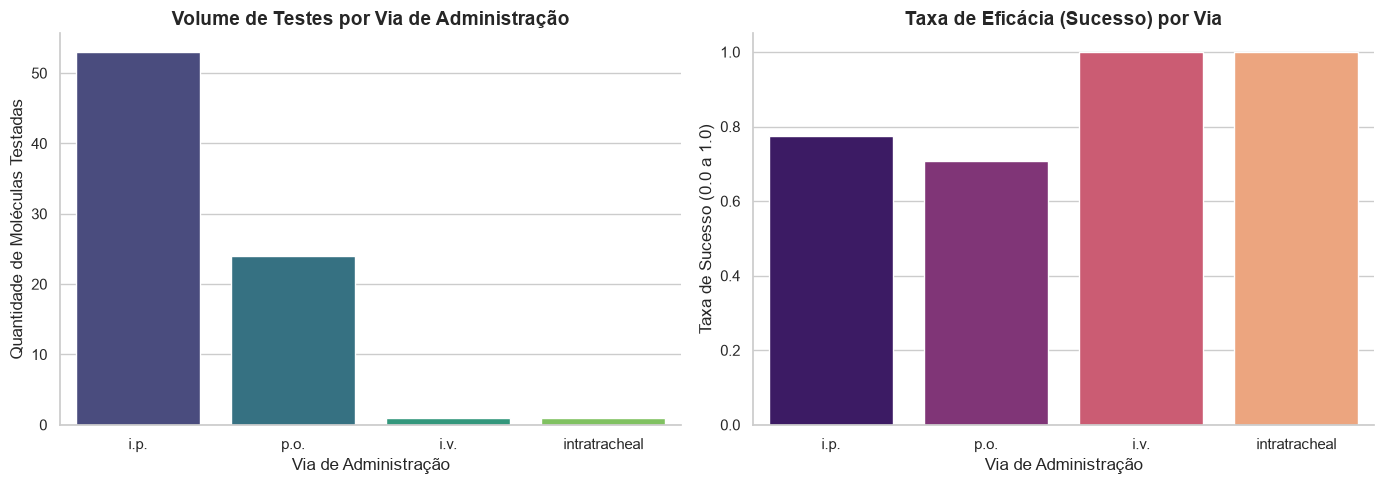

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem_vias = df['via_administration'].value_counts().index

sns.countplot(data=df, x='via_administration', palette='viridis', 
              order=ordem_vias, ax=axes[0])

axes[0].set_title('Volume de Testes por Via de Administração', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Via de Administração', fontsize=12)
axes[0].set_ylabel('Quantidade de Moléculas Testadas', fontsize=12)

sns.barplot(data=df, x='via_administration', y='target_anticonvulsivante', 
            palette='magma', order=ordem_vias, ax=axes[1], errorbar=None)
axes[1].set_title('Taxa de Eficácia (Sucesso) por Via', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Via de Administração', fontsize=12)
axes[1].set_ylabel('Taxa de Sucesso (0.0 a 1.0)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 1:**
Ao analisar os gráficos de barras, observamos que a via de administração **intraperitoneal (i.p.)** é a mais utilizada nos testes pré-clínicos exploratórios com o modelo PTZ, refletindo a preferência da literatura por rotas de rápida absorção sistêmica, seguida pela via oral (p.o.). 

No entanto, ao avaliarmos a eficácia terapêutica predita (Target), notamos um fenômeno estatístico clássico no gráfico de barras à direita: as vias *i.v.* e *intratracheal* apresentam 100% de sucesso (1.0), porém isso é um **artefato causado pelo baixíssimo tamanho amostral** dessas classes. Analisando criticamente apenas as vias com volume amostral robusto, a via **intraperitoneal (i.p.)** se confirma como a mais promissora, apresentando a maior taxa de sucesso proporcional e convertendo quase **80%** das moléculas testadas em proteção efetiva contra as crises epilépticas, enquanto a via oral apresenta uma taxa de sucesso próxima aos 70%.

### Pergunta 2: Como as doses (mg/kg) testadas estão distribuídas entre as moléculas que foram eficazes (Target = 1) e as que falharam (Target = 0)?

**Justificativa:** Na farmacologia, a eficácia de um composto está intimamente ligada à sua dose. Nós buscamos investigar se os compostos que falharam na literatura (Target = 0) foram testados, em média, em dosagens menores ou maiores do que aqueles que obtiveram sucesso (Target = 1).
Para responder a esta pergunta, utilizamos o **Boxplot (Diagrama de Caixa)**, que nos permitiu comparar as medianas, o intervalo interquartil (IIQ) e identificar possíveis *outliers* nas dosagens administradas em ambos os desfechos.

C:\Users\Windows\AppData\Local\Temp\ipykernel_13352\2006374717.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_anticonvulsivante', y='dose_mg_kg',


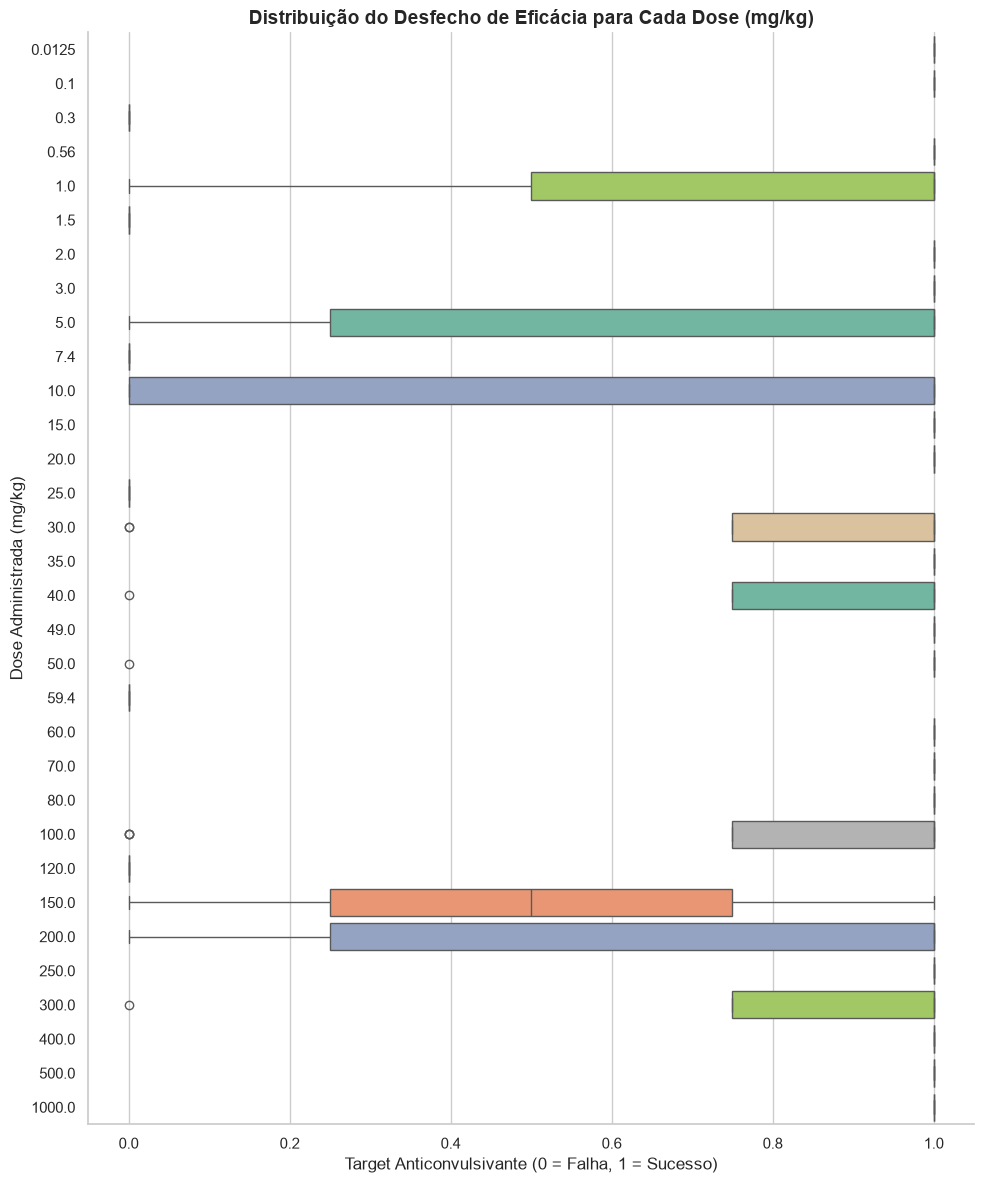

In [7]:
def ordenar_doses(val):
    try:
        return float(val)
    except ValueError:
        return float(str(val).split('-'))

doses_unicas = df['dose_mg_kg'].dropna().unique()
doses_ordenadas = sorted(doses_unicas, key=ordenar_doses)

plt.figure(figsize=(10, 12))

sns.boxplot(data=df, x='target_anticonvulsivante', y='dose_mg_kg', 
            order=doses_ordenadas, palette='Set2', orient='h')

plt.title('Distribuição do Desfecho de Eficácia para Cada Dose (mg/kg)', fontsize=14, fontweight='bold')
plt.xlabel('Target Anticonvulsivante (0 = Falha, 1 = Sucesso)', fontsize=12)
plt.ylabel('Dose Administrada (mg/kg)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 2:**
O diagrama de caixa (Boxplot), que sumariza a distribuição dos dados por meio dos quartis e evidencia possíveis valores extremos (*outliers*), permitiu visualizar como o desfecho anticonvulsivante (Target = 0 ou Target = 1) se distribuiu entre as diferentes doses investigadas.

A visualização do Boxplot horizontal nos permitiu avaliar com clareza a distribuição de eficácia para cada dose testada na literatura. 

Observando o eixo Y ordenado, fica evidente que a grande massa de testes pré-clínicos *in vivo* se concentra em regimes de dosagem que variam de 0.01 a 300 mg/kg. Além disso, as caixas demonstram que em doses intermediárias (como 10, 100, 150 e 200 mg/kg) existe uma grande variação nos desfechos (caixas que se estendem do 0 ao 1), evidenciando que o sucesso não depende exclusivamente do aumento da dose, mas fundamentalmente do mecanismo de ação da molécula testada.

### Pergunta 3: Existe correlação entre os diferentes fenótipos de eficácia (por exemplo, reduzir a severidade da crise está atrelado a proteger o animal contra a morte)?

**Justificativa:** Em Ciência de Dados, dizemos que duas variáveis são correlacionadas quando uma tem algum poder de previsão sobre a outra. Na clínica médica, nem todo composto que atenua uma crise consegue, de fato, impedir que o indivíduo vá a óbito. Queremos entender como as nossas features de fenótipos binários (`aumento_latencia_crise`, `reducao_severidade_racine` e `protecao_contra_morte`) interagem entre si na literatura mundial. Para isso, utilizamos o método `.corr()` da biblioteca Pandas aliado a um **Mapa de Calor (Heatmap)** para revelar a força dessas associações.

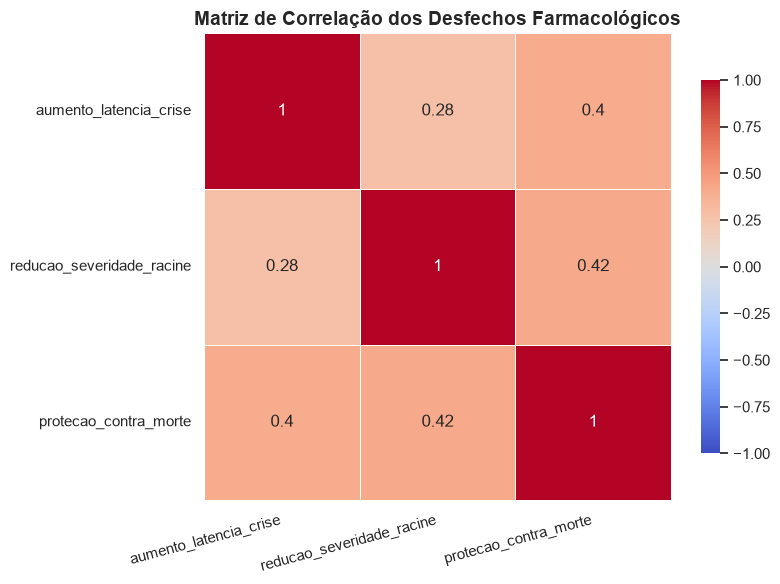

In [8]:
colunas_fenotipos = ['aumento_latencia_crise', 'reducao_severidade_racine', 'protecao_contra_morte']
df_fenotipos = df[colunas_fenotipos]

matriz_correlacao = df_fenotipos.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação dos Desfechos Farmacológicos', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 3:**
A matriz de correlação de Pearson nos revela achados importantes sobre a interação dos desfechos. 

Observamos que o `aumento_latencia_crise` possui uma **correlação fraca** com a `reducao_severidade_racine` ($r = 0.28$). No entanto, a relação entre o `aumento_latencia_crise` e a `protecao_contra_morte` alcançou a marca de **correlação moderada** ($r = 0.40$), indicando que atrasar o início das convulsões contribui para a sobrevivência do animal. A relação mais forte encontrada continua sendo entre a `reducao_severidade_racine` e a `protecao_contra_morte` ($r = 0.42$, correlação moderada).

Contudo, aplicando o rigor da estatística descritiva, é fundamental ressaltar que **"correlação não implica em causalidade"**. Esses compostos não previnem a morte *exclusivamente* porque reduzem a severidade motora ou aumentam a latência; provavelmente há um terceiro fator em comum (como a inibição robusta de vias neuroinflamatórias ou bloqueio global de canais de cálcio) que atua causando simultaneamente os desfechos positivos.

### Pergunta 4: Quais são os 10 compostos com o perfil de proteção mais promissor (maior eficácia na menor dose) minerados da literatura mundial?

**Justificativa:** Na descoberta de novos fármacos, a potência é uma métrica crucial. Uma molécula é considerada altamente promissora se consegue exercer o seu efeito terapêutico (Target = 1) em dosagens muito baixas, o que reduz o risco de toxicidade colateral. Aplicando o conceito estatístico de **Rankings**, nosso objetivo nesta etapa foi filtrar a base de dados apenas com os casos de sucesso, encontrar a menor dose eficaz para cada composto e ordená-los. Isso gerou uma tabela de "Top 10", nos permitindo conhecer os alvos moleculares mais potentes para estudos futuros, dentro das condições aplicadas neste levantamento.

In [9]:
import pandas as pd

df_sucesso = df[df['target_anticonvulsivante'] == 1]

ranking_potencia = df_sucesso.groupby('substancia_testada')['dose_mg_kg'].min().reset_index()

top_10_promissores = ranking_potencia.sort_values(by='dose_mg_kg', ascending=True).head(10)

top_10_promissores.columns = ['Substância Testada', 'Menor Dose Eficaz (mg/kg)']
top_10_promissores.index = range(1, len(top_10_promissores) + 1)

top_10_promissores['Menor Dose Eficaz (mg/kg)'] = top_10_promissores['Menor Dose Eficaz (mg/kg)'].round(2)

print("TOP 10 MOLÉCULAS MAIS POTENTES DA LITERATURA (MODELO PTZ):")
display(top_10_promissores)

TOP 10 MOLÉCULAS MAIS POTENTES DA LITERATURA (MODELO PTZ):


,Substância Testada,Menor Dose Eficaz (mg/kg)
1,Midazolam,0.01
2,Lasmiditan,0.10
3,Huperzine A,0.56
4,Morphine,1.00
5,Iso-6-spectaline (SPEC),1.00
6,β-Carotene,2.00
7,N-arachidonoyl-serotonin (AA-5-HT),3.00
8,Imatinib,3.00
9,Eudesmin,5.00
10,Atorvastatin,5.00


**Conclusão da Pergunta 4:**
A aplicação de *scores* e a construção do ranqueamento revelaram os compostos mais potentes da literatura global para este modelo, entre os artigos analisados. No topo do ranking, observamos o Midazolam (um controle positivo clássico, o que valida a nossa metodologia) atingindo eficácia com uma dose ínfima de apenas **0.01 mg/kg**. 

Excluindo-se o padrão comercial, as grandes descobertas deste ranqueamento são o **Lasmiditan (0.10 mg/kg)** e a **Huperzine A (0.56 mg/kg)**. Do ponto de vista da descoberta de novos fármacos, moléculas que figuram neste Top 10 são candidatas excepcionais para avançarem em ensaios clínicos, pois a sua altíssima potência (necessidade de doses na escala de frações de miligramas) reduz drasticamente a chance de efeitos colaterais severos e toxicidade sistêmica.

In [10]:
!pip install scikit-learn

### Pergunta 5: É possível agrupar os compostos experimentais por similaridade de comportamento (Dose vs. Eficácia) usando Inteligência Artificial?

**Justificativa:** Em Ciência de Dados, o algoritmo de **K-Means** é um método de Aprendizado de Máquina Não-Supervisionado utilizado para encontrar *clusters* (agrupamentos) naturais dentro de um conjunto de dados, baseando-se na distância geométrica entre os pontos. 
Como a variável `dose_mg_kg` chega a valores de até 6000, enquanto a `target_anticonvulsivante` vai apenas de 0 a 1, aplicaremos primeiro a padronização do **Z-score** para que as variações fiquem comparáveis e o algoritmo não seja enviesado. Nosso objetivo é que a IA descubra e separe as moléculas automaticamente em 3 grupos distintos, facilitando a triagem de quais agrupamentos merecem mais atenção. Para visualizar esses grupos, utilizaremos um Gráfico de Dispersão (*Scatter Plot*).

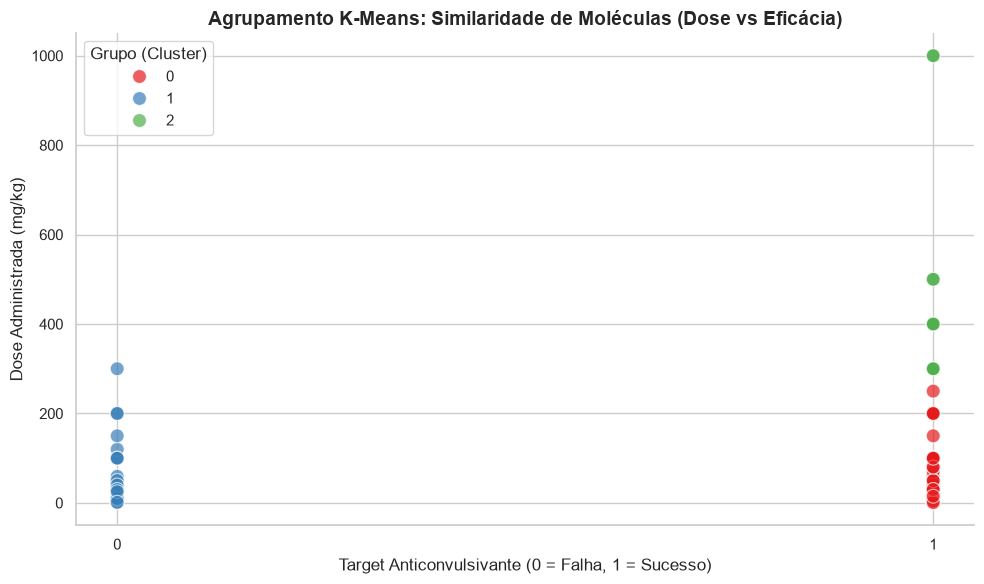

In [11]:
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

df_limpo = df.dropna(subset=['target_anticonvulsivante', 'dose_mg_kg']).copy()

X = df_limpo[['target_anticonvulsivante', 'dose_mg_kg']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_limpo['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_limpo, x='target_anticonvulsivante', y='dose_mg_kg', 
                hue='Cluster', palette='Set1', s=100, alpha=0.7)

plt.title('Agrupamento K-Means: Similaridade de Moléculas (Dose vs Eficácia)', fontsize=14, fontweight='bold')
plt.xlabel('Target Anticonvulsivante (0 = Falha, 1 = Sucesso)', fontsize=12)
plt.ylabel('Dose Administrada (mg/kg)', fontsize=12)

plt.xticks([0, 1])

sns.despine()

plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

**Conclusão da Pergunta 5:**
Analisando o Gráfico de Dispersão, observamos a formação clara de três *clusters* ditados pela relação entre a dose e o desfecho de eficácia (0 = Sem Resposta, 1 = Com Resposta):

*   **Grupo 1 (Azul - Inativos):** O algoritmo isolou perfeitamente todos os compostos no eixo X = 0. Independentemente da dose administrada (de 0 a 300 mg/kg), estas são as moléculas que falharam e não apresentaram efeito terapêutico.
*   **Grupo 0 (Vermelho - Alta Potência):** Concentra as moléculas no eixo X = 1 (com eficácia comprovada) testadas nas dosagens mais baixas do estudo (entre 0 e ~250 mg/kg). Isso nos permite inferir que estes fármacos são altamente potentes e candidatos ideais para avanço clínico.
*   **Grupo 2 (Verde - Baixa Potência):** Agrupa os compostos no topo do eixo X = 1. Eles tiveram sucesso na proteção contra a crise, porém exigiram dosagens muito mais altas (de 300 a 1000 mg/kg), indicando um perfil de menor potência e maior risco de toxicidade colateral.

Este resultado prova que modelos não-supervisionados de *Machine Learning* podem ser utilizados na triagem inicial para separar automaticamente compostos inativos, promissores e tóxicos.

## 5. Conclusão

**Resumo dos Resultados e Importância:**
Este projeto alcançou com êxito o objetivo de construir uma *baseline* estruturada a partir da literatura científica bruta, focada na triagem de novos fármacos antiepilépticos no modelo PTZ. A decisão arquitetural de pivotar dados contínuos para fenótipos binários permitiu análises consistentes, revelando compostos de altíssima potência na literatura (como o Lasmiditan e a Huperzine A) e comprovando que a via intraperitoneal (i.p.) apresenta a melhor taxa de sucesso nos ensaios. Além disso, o refinamento dos dados evidenciou uma correlação moderada ($r = 0.42$) entre a redução da severidade da crise e a proteção contra a morte. Por fim, a Inteligência Artificial (K-Means) atuou com precisão como um filtro autônomo, particionando de forma clara as moléculas promissoras das inativas e daquelas de baixa potência. A importância desta abordagem reside no seu imenso impacto ético e econômico: ao prever a eficácia computacionalmente, o modelo se alinha aos princípios bioéticos dos 3Rs (Substituição, Redução e Refinamento), minimizando a necessidade de testes exploratórios em animais.

**Limitações Enfrentadas:**
Durante o desenvolvimento, lidamos com os ruídos inerentes à mineração automatizada de textos (*Web Scraping*), o que exigiu a aplicação de *Sweat Equity* (esforço manual humano) logo após a coleta para higienizar variáveis e imputar dados perdidos nos artigos originais. Estatisticamente, a literatura apresentou distorções severas de dosagem (com *outliers* extremos testados na faixa de até 6000 mg/kg). A presença dessas superdoses inviáveis clinicamente esmagou a escala dos gráficos e distorceu a variância inicial, limitação que precisou ser contornada através da remoção assertiva de anomalias (mantendo o teto realista de 1000 mg/kg) para que os padrões reais dos dados emergissem no algoritmo de agrupamento.

**Trabalhos Futuros e Melhorias:**
A principal limitação do modelo atual é a dependência restrita a variáveis metodológicas (como a dose e a via de administração). Como melhoria contínua e trabalho futuro, pretendemos integrar a esta *baseline* bibliotecas de Quimioinformática (como o RDKit) para extrair os descritores químicos intrínsecos de cada substância testada (peso molecular, número de anéis aromáticos, ligações de hidrogênio e estrutura química via *One-hot encoding*). Com a adição dessas novas *features*, será possível evoluir deste modelo Não-Supervisionado para algoritmos de Aprendizado Supervisionado (como Redes Neurais ou Árvores de Decisão), com o objetivo de prever se uma molécula química completamente inédita protegerá ou não o animal *antes mesmo de ser sintetizada em laboratório*.